In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Mean & Median Imputation


Advatanges

*   Simple To Use and Implement
*   When the Missing Value under the 5% (< 5%) then it is useful
*   Easy to write and reuseable

---

Disadvatages

*   Change the Shape of the Distribution
*   Make Outliers
*   Changes in Covarience and Correlation
---
When to Use this Method

1.   Missing Value in Random place
2.   When Data is 5% or less than missing Dataset


In [ ]:
df = pd.read_csv('/content/train.csv',usecols = ['Age','Fare','SibSp','Parch','Survived'])

## Using Pandas Imputation

In [ ]:
df['Famliy'] = df['SibSp'] + df['Parch']

In [ ]:
df.drop(['SibSp','Parch'],axis = 1,inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
 3   Famliy    891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [ ]:
df.isnull().mean()

,0
Survived,0.000000
Age,0.198653
Fare,0.000000
Famliy,0.000000


In [ ]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [ ]:
x_train.isnull().mean()

,0
Age,0.196629
Fare,0.000000
Famliy,0.000000


In [ ]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_age,median_age

(np.float64(29.498846153846156), 28.0)

In [ ]:
x_train['age_mean'] = x_train['Age'].fillna(mean_age)
x_train['age_median'] = x_train['Age'].fillna(median_age)

In [ ]:
x_train.sample(5)

,Age,Fare,Famliy,age_mean,age_median
662,47.0,25.5875,0,47.0,47.0
862,48.0,25.9292,0,48.0,48.0
619,26.0,10.5000,0,26.0,26.0
394,24.0,16.7000,2,24.0,24.0
543,32.0,26.0000,1,32.0,32.0


In [ ]:
print('Original Age Variable varieance',x_train['Age'].var())
print('Age varieance after mean imputation',x_train['age_mean'].var())
print('Age varieance after median imputation',x_train['age_median'].var())

Original Age Variable varieance 210.2517072477438
Age varieance after mean imputation 168.8519336687225
Age varieance after median imputation 169.20731007048096


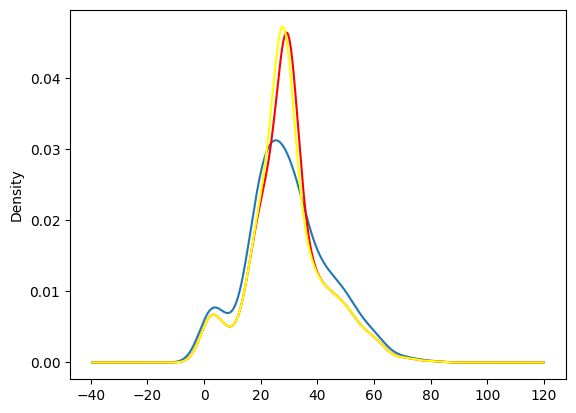

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable Distribution
x_train['Age'].plot(kind = 'kde',ax = ax)

# Variable imputed with mean
x_train['age_mean'].plot(kind = 'kde',ax = ax,color = 'red')

# Variable imputed with median
x_train['age_median'].plot(kind = 'kde',ax = ax,color = 'yellow')

plt.show()

In [ ]:
x_train.cov(0)

,Age,Fare,Famliy,age_mean,age_median
Age,210.251707,71.580633,-6.993325,210.251707,210.251707
Fare,71.580633,2700.831981,18.495747,57.485994,61.261919
Famliy,-6.993325,18.495747,2.830892,-5.616299,-5.587710
age_mean,210.251707,57.485994,-5.616299,168.851934,168.851934
age_median,210.251707,61.261919,-5.587710,168.851934,169.207310


In [ ]:
x_train.corr()

,Age,Fare,Famliy,age_mean,age_median
Age,1.000000,0.088103,-0.319651,1.000000,1.000000
Fare,0.088103,1.000000,0.211525,0.085126,0.090622
Famliy,-0.319651,0.211525,1.000000,-0.256883,-0.255307
age_mean,1.000000,0.085126,-0.256883,1.000000,0.998949
age_median,1.000000,0.090622,-0.255307,0.998949,1.000000


<Axes: >

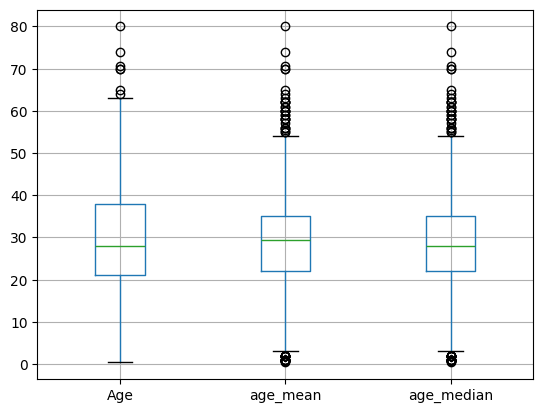

In [ ]:
x_train[['Age','age_mean','age_median']].boxplot()

## Using Sklearn Imputation

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
imputer1 = SimpleImputer(strategy = 'median')

In [ ]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),

],remainder = 'passthrough')


In [ ]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age'])])

In [ ]:
trf.named_transformers_

{'imputer1': SimpleImputer(strategy='median'),
 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                     feature_names_out='one-to-one')}

In [ ]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [ ]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [ ]:
x_train


array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.1083,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]])

# Arbitrary Value Impuatation


Advatanges

*   Simple To Use and Implement

---

Disadvatages

*   Change the Shape of the Distribution
*   Changes in Covarience and Correlation
---
When to Use this Method

1.   Missing Value Not in Random place
2.   When Data is 5% or less than missing Dataset


In [ ]:
df1 = pd.read_csv('/content/train.csv',usecols = ['Age','Fare','SibSp','Parch','Survived'])

In [ ]:
df1.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [ ]:
df1.isnull().mean()

,0
Survived,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Fare,0.000000


## Using Pandas Imputation

In [ ]:
x = df1.drop(columns=['Survived'])
y = df1['Survived']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
x_train['age_99'] = x_train['Age'].fillna(99)
x_train['age_minus_one'] = x_train['Age'].fillna(-1)

In [ ]:
print('Original Age Variable varieance',x_train['Age'].var())
print('Age varieance after mean imputation',x_train['age_99'].var())
print('Age varieance after median imputation',x_train['age_minus_one'].var())

Original Age Variable varieance 210.2517072477438
Age varieance after mean imputation 932.9665366701436
Age varieance after median imputation 315.99550362600644


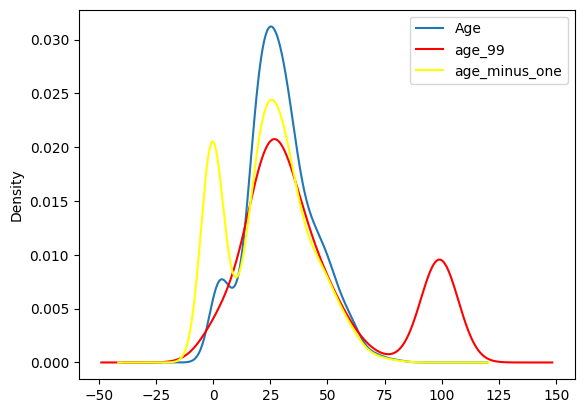

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable Distribution
x_train['Age'].plot(kind = 'kde',ax = ax)

# Variable imputed with mean
x_train['age_99'].plot(kind = 'kde',ax = ax,color = 'red')

# Variable imputed with median
x_train['age_minus_one'].plot(kind = 'kde',ax = ax,color = 'yellow')

# Add Legend
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc = 'best')
plt.show()

In [ ]:
x_train.cov()

,Age,SibSp,Parch,Fare,age_99,age_minus_one
Age,210.251707,-4.501273,-2.492052,71.580633,210.251707,210.251707
SibSp,-4.501273,1.383927,0.410112,9.354652,-2.585812,-4.066556
Parch,-2.492052,0.410112,0.626740,9.141094,-4.356170,-0.968000
Fare,71.580633,9.354652,9.141094,2700.831981,-117.602795,134.319337
age_99,210.251707,-2.585812,-4.356170,-117.602795,932.966537,-166.460682
age_minus_one,210.251707,-4.066556,-0.968000,134.319337,-166.460682,315.995504


In [ ]:
x_train.corr()

,Age,SibSp,Parch,Fare,age_99,age_minus_one
Age,1.000000,-0.320916,-0.207040,0.088103,1.000000,1.000000
SibSp,-0.320916,1.000000,0.440355,0.153011,-0.071963,-0.194460
Parch,-0.207040,0.440355,1.000000,0.222180,-0.180147,-0.068785
Fare,0.088103,0.153011,0.222180,1.000000,-0.074086,0.145395
age_99,1.000000,-0.071963,-0.180147,-0.074086,1.000000,-0.306576
age_minus_one,1.000000,-0.194460,-0.068785,0.145395,-0.306576,1.000000


## Using Sklearn Imputation

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
imputer1 = SimpleImputer(strategy = 'constant',fill_value=99)

In [ ]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),

],remainder = 'passthrough')

In [ ]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age'])])

In [ ]:
trf.named_transformers_

{'imputer1': SimpleImputer(fill_value=99, strategy='constant'),
 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                     feature_names_out='one-to-one')}

In [ ]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [ ]:
x_train = trf.fit_transform(x_train)
x_test = trf.transform(x_test)

In [ ]:
x_train

array([[ 45.5   ,   0.    ,   0.    ,  28.5   ],
       [ 23.    ,   0.    ,   0.    ,  13.    ],
       [ 32.    ,   0.    ,   0.    ,   7.925 ],
       ...,
       [ 41.    ,   2.    ,   0.    ,  14.1083],
       [ 14.    ,   1.    ,   2.    , 120.    ],
       [ 21.    ,   0.    ,   1.    ,  77.2875]])

# End of Distribution Impuatation

Advatanges

*   Simple To Use and Implement

---

Disadvatages

*   Change the Shape of the Distribution
*   Changes in Covarience and Correlation
---
When to Use this Method

1.   Missing Value Not in Random place
2.   When Data is 5% or less than missing Dataset
